# 04 - Allen-Cahn Equation Experiments
**AC-PINN Project** | Authors: Suyash Vasal Jain, Nishita Raghvendra

**PDE:** $u_t = \varepsilon^2 u_{xx} + u - u^3$, $\varepsilon = 0.01$

**IC:** $u(x,0) = x^2 \cos(\pi x)$ | **BC:** $u(-1,t) = u(1,t) = 0$

**Domain:** $x \in [-1,1]$, $t \in [0,1]$

**Architecture:** `[2, 128, 128, 128, 128, 128, 1]` | **Epochs:** 10000

**Note:** Allen-Cahn is the hardest test. Stiff PDE with sharp interface.
Vanilla PINN is known to fail here. This is AC-PINN's strongest showcase.

In [1]:
import sys, os
sys.path.append('..')
import torch
import numpy as np
import matplotlib.pyplot as plt
from pinn_base import (
    device, NoisyDataGenerator, PINNSolver, ACPINNSolver,
    AllenCahnFDM, Benchmark, save_metrics, save_history
)

PDE        = 'allen_cahn'
LAYERS     = [2, 128, 128, 128, 128, 128, 1]
EPOCHS     = 10000
PDE_PARAMS = {'epsilon': 0.01}
RESULTS    = '../results/allen_cahn/'
FIGURES    = '../figures/allen_cahn/'
os.makedirs(RESULTS, exist_ok=True)
os.makedirs(FIGURES, exist_ok=True)

gen = NoisyDataGenerator(pde=PDE)
print(f'Device: {device}')

Device: cuda


## Section 1 - FDM Ground Truth

AllenCahnFDM solved in 1.7323s


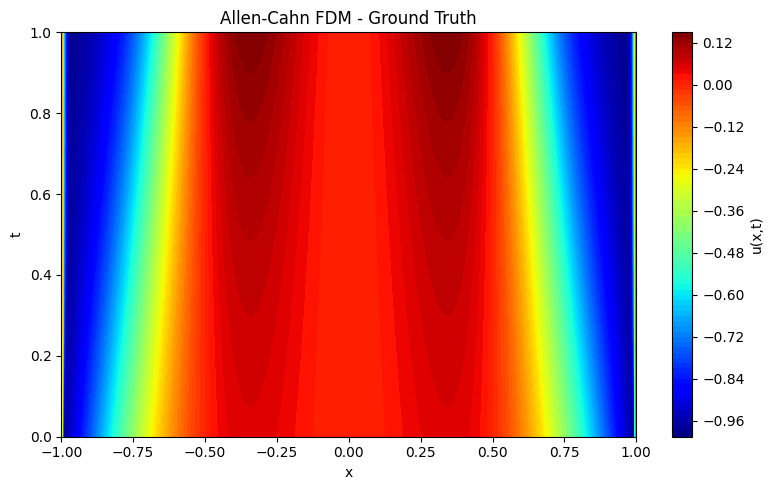

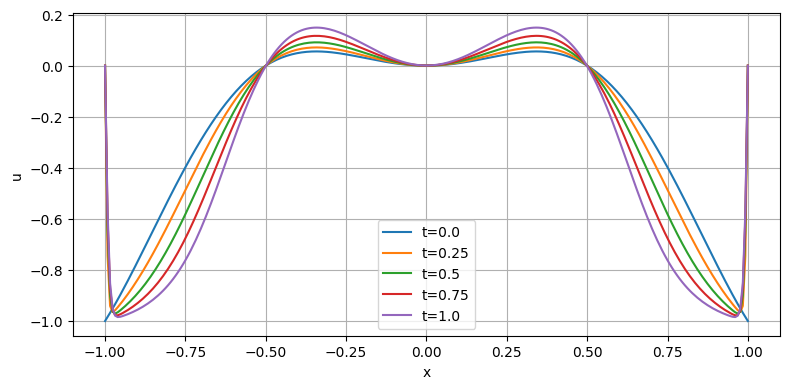

In [2]:
fdm = AllenCahnFDM(nx=256, nt=5000, epsilon=0.01)
fdm.solve()
fdm.plot_solution(title='Allen-Cahn FDM - Ground Truth')
fdm.plot_time_slices()

## Section 2 - Data Conditions

In [3]:
# Allen-Cahn needs more collocation points due to stiffness
data_clean_dense  = gen.generate(N_ic=1000, N_bc=1000, N_f=10000, noise_eps=0.0)
data_noisy_sparse = gen.generate(N_ic=20,   N_bc=20,   N_f=3000,  noise_eps=0.1)
print('Data ready')

Data ready


## Section 3 - Vanilla PINN, Clean Dense

D:\PINN\ac-pinn-project\ac-pinn-project\venv\Lib\site-packages\torch\autograd\graph.py:825: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch     0 | Total: 0.367864 | IC: 0.137916 | BC: 0.034997 | PDE: 0.019495


Epoch  1000 | Total: 0.128693 | IC: 0.121657 | BC: 0.003992 | PDE: 0.000304


Epoch  2000 | Total: 0.128586 | IC: 0.121597 | BC: 0.003898 | PDE: 0.000309


Epoch  3000 | Total: 0.129641 | IC: 0.124851 | BC: 0.003495 | PDE: 0.000129


...

Epoch  6000 | Total: 0.063085 | IC: 0.056527 | BC: 0.002845 | PDE: 0.000371


Epoch  7000 | Total: 0.045730 | IC: 0.039432 | BC: 0.001421 | PDE: 0.000488


Epoch  8000 | Total: 0.050222 | IC: 0.032972 | BC: 0.011465 | PDE: 0.000578


Epoch  9000 | Total: 0.039627 | IC: 0.034422 | BC: 0.000786 | PDE: 0.000442



Training complete in 288.51s


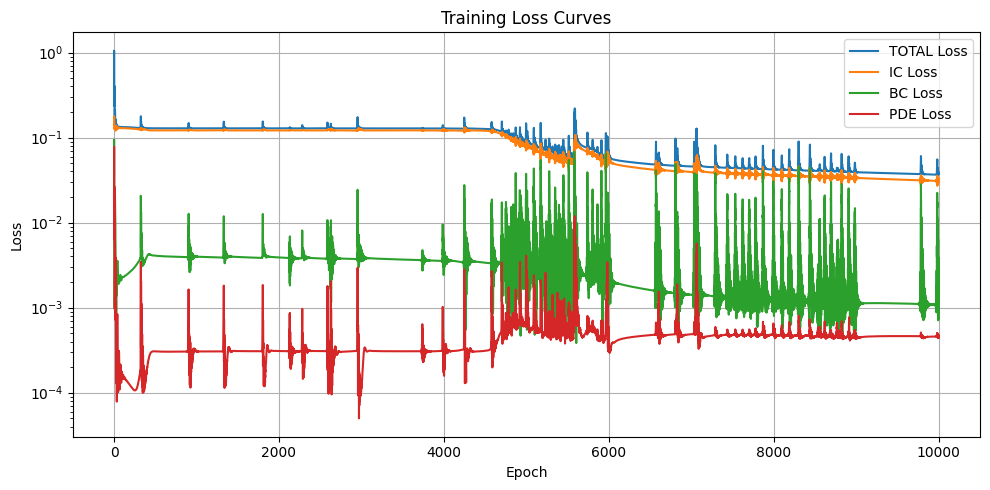

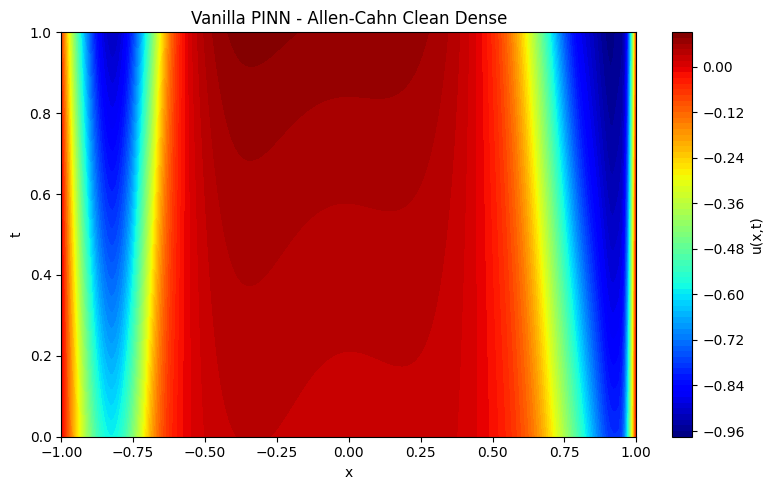

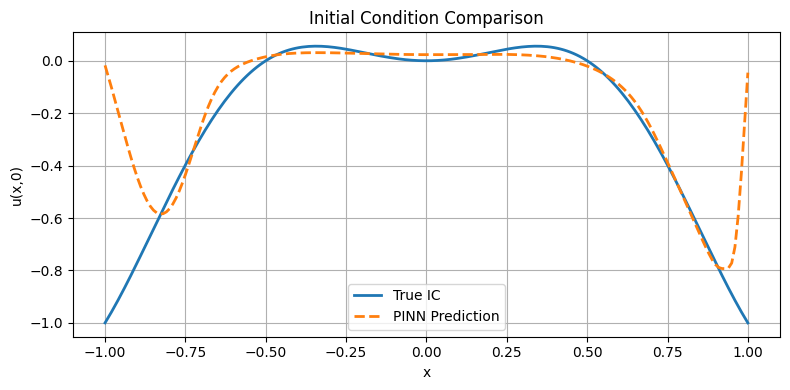

Saved: ../results/allen_cahn/vanilla_clean_history.npy


In [4]:
# Higher lambda_pde for stiff PDE
vanilla_clean = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS,
                            lambda_ic=1.0, lambda_bc=1.0, lambda_pde=10.0)
h_vc = vanilla_clean.fit(data_clean_dense, epochs=EPOCHS, print_every=1000, label='Allen-Cahn | Vanilla Clean')
vanilla_clean.plot_loss_history(h_vc)
vanilla_clean.plot_solution(title='Vanilla PINN - Allen-Cahn Clean Dense')
vanilla_clean.plot_initial_condition_comparison(gen)
save_history(h_vc, RESULTS+'vanilla_clean_history.npy')

## Section 4 - Vanilla PINN, Noisy Sparse
⚠️ Vanilla PINN typically fails here on Allen-Cahn.

Epoch     0 | Total: 0.152333 | IC: 0.070189 | BC: 0.036956 | PDE: 0.004519


Epoch  1000 | Total: 0.093467 | IC: 0.067141 | BC: 0.025633 | PDE: 0.000069


Epoch  2000 | Total: 0.093431 | IC: 0.067176 | BC: 0.025532 | PDE: 0.000072


Epoch  3000 | Total: 0.093506 | IC: 0.067303 | BC: 0.025543 | PDE: 0.000066


Epoch  4000 | Total: 0.092873 | IC: 0.066412 | BC: 0.025251 | PDE: 0.000121


...

Epoch  6000 | Total: 0.082913 | IC: 0.055291 | BC: 0.023882 | PDE: 0.000374


Epoch  7000 | Total: 0.033886 | IC: 0.010179 | BC: 0.022230 | PDE: 0.000148


Epoch  8000 | Total: 0.032550 | IC: 0.009824 | BC: 0.021526 | PDE: 0.000120


Epoch  9000 | Total: 0.031835 | IC: 0.009582 | BC: 0.020940 | PDE: 0.000131



Training complete in 136.30s


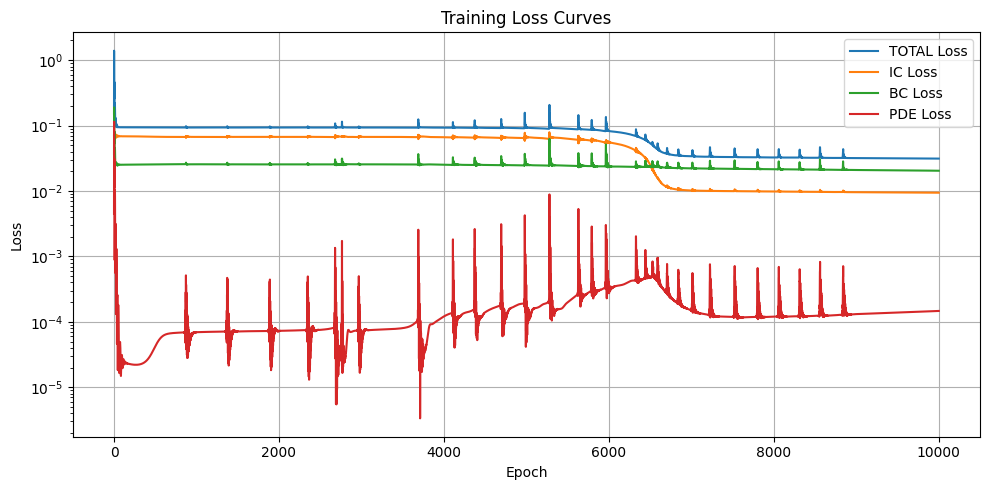

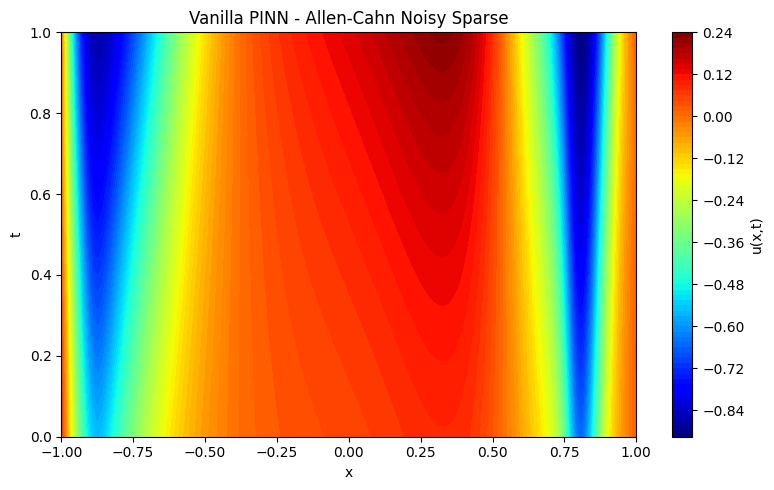

Saved: ../results/allen_cahn/vanilla_noisy_history.npy


In [5]:
vanilla_noisy = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS,
                            lambda_ic=1.0, lambda_bc=1.0, lambda_pde=10.0)
h_vn = vanilla_noisy.fit(data_noisy_sparse, epochs=EPOCHS, print_every=1000, label='Allen-Cahn | Vanilla Noisy')
vanilla_noisy.plot_loss_history(h_vn)
vanilla_noisy.plot_solution(title='Vanilla PINN - Allen-Cahn Noisy Sparse')
save_history(h_vn, RESULTS+'vanilla_noisy_history.npy')

## Section 5 - AC-PINN, Clean Dense

Epoch     0 | Stage 1/4 | Total: 0.623046 | IC: 0.194883 | BC: 0.391381 | PDE: 0.007356 | λ=(1.00,1.00,5.00)


Epoch  1000 | Stage 1/4 | Total: 0.038008 | IC: 0.003546 | BC: 0.011742 | PDE: 0.000018 | λ=(2.16,2.58,6.75)


Epoch  2000 | Stage 1/4 | Total: 0.017042 | IC: 0.001650 | BC: 0.006448 | PDE: 0.000014 | λ=(2.09,2.09,10.00)


Epoch  3000 | Stage 2/4 | Total: 0.023199 | IC: 0.014055 | BC: 0.000808 | PDE: 0.000009 | λ=(1.25,6.93,10.00)


Epoch  4000 | Stage 2/4 | Total: 0.010559 | IC: 0.001363 | BC: 0.003277 | PDE: 0.000000 | λ=(1.68,2.52,10.00)


...

Epoch  6000 | Stage 3/4 | Total: 0.031059 | IC: 0.011444 | BC: 0.001392 | PDE: 0.000002 | λ=(2.67,0.33,0.10)


Epoch  7000 | Stage 3/4 | Total: 0.007415 | IC: 0.000158 | BC: 0.002612 | PDE: 0.000001 | λ=(0.17,2.83,0.10)


Epoch  8000 | Stage 4/4 | Total: 0.404686 | IC: 0.135048 | BC: 0.000065 | PDE: 0.000093 | λ=(3.00,0.10,0.10)


Epoch  9000 | Stage 4/4 | Total: 0.699922 | IC: 0.004930 | BC: 0.189554 | PDE: 0.268232 | λ=(0.10,1.23,1.74)



AC-PINN training complete in 306.07s


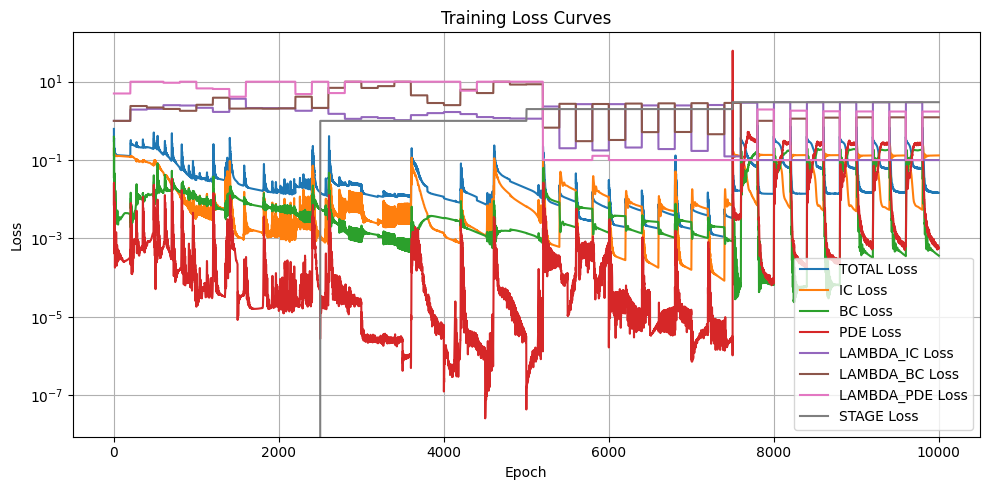

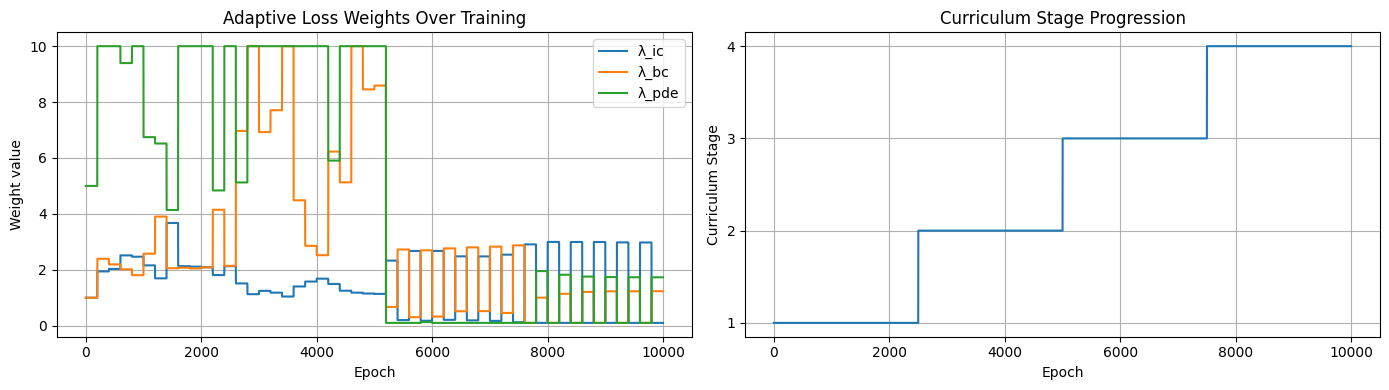

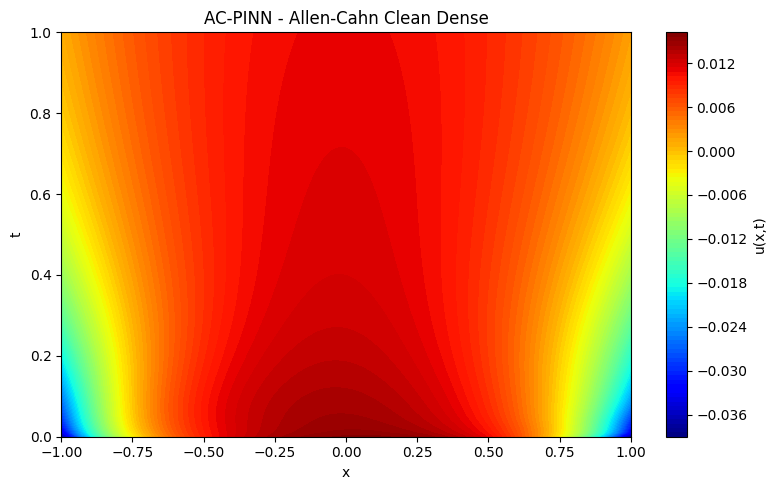

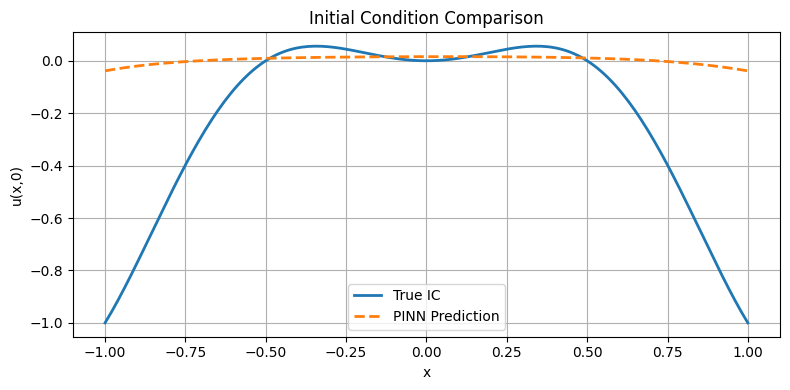

Saved: ../results/allen_cahn/ac_clean_history.npy


In [6]:
ac_clean = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS,
                         weight_strategy='both',
                         N_pool=30000, resample_every=500)
h_ac = ac_clean.fit(data_clean_dense, epochs=EPOCHS, print_every=1000, label='Allen-Cahn | AC-PINN Clean')
ac_clean.plot_loss_history(h_ac)
ac_clean.plot_weight_history(h_ac)
ac_clean.plot_solution(title='AC-PINN - Allen-Cahn Clean Dense')
ac_clean.plot_initial_condition_comparison(gen)
save_history(h_ac, RESULTS+'ac_clean_history.npy')

## Section 6 - AC-PINN, Noisy Sparse
This is where AC-PINN should demonstrate its biggest advantage.

Epoch     0 | Stage 1/4 | Total: 0.115929 | IC: 0.075798 | BC: 0.039205 | PDE: 0.000185 | λ=(1.00,1.00,5.00)


Epoch  1000 | Stage 1/4 | Total: 0.086831 | IC: 0.029206 | BC: 0.011065 | PDE: 0.000165 | λ=(1.42,3.95,10.00)


Epoch  2000 | Stage 1/4 | Total: 0.031510 | IC: 0.009634 | BC: 0.005483 | PDE: 0.000017 | λ=(1.93,2.32,10.00)


Epoch  3000 | Stage 2/4 | Total: 0.089529 | IC: 0.008069 | BC: 0.006526 | PDE: 0.000055 | λ=(10.00,1.31,5.27)


Epoch  4000 | Stage 2/4 | Total: 0.040073 | IC: 0.005518 | BC: 0.005859 | PDE: 0.000351 | λ=(5.23,1.56,5.94)


...

Epoch  6000 | Stage 3/4 | Total: 0.014034 | IC: 0.004426 | BC: 0.005534 | PDE: 0.000979 | λ=(1.21,1.52,0.27)


Epoch  7000 | Stage 3/4 | Total: 0.013764 | IC: 0.004327 | BC: 0.005379 | PDE: 0.000831 | λ=(1.23,1.53,0.24)


Epoch  8000 | Stage 4/4 | Total: 0.132815 | IC: 0.016263 | BC: 0.012677 | PDE: 0.058824 | λ=(0.56,0.43,2.01)


Epoch  9000 | Stage 4/4 | Total: 0.068244 | IC: 0.025778 | BC: 0.019205 | PDE: 0.000474 | λ=(1.70,1.27,0.10)



AC-PINN training complete in 160.42s


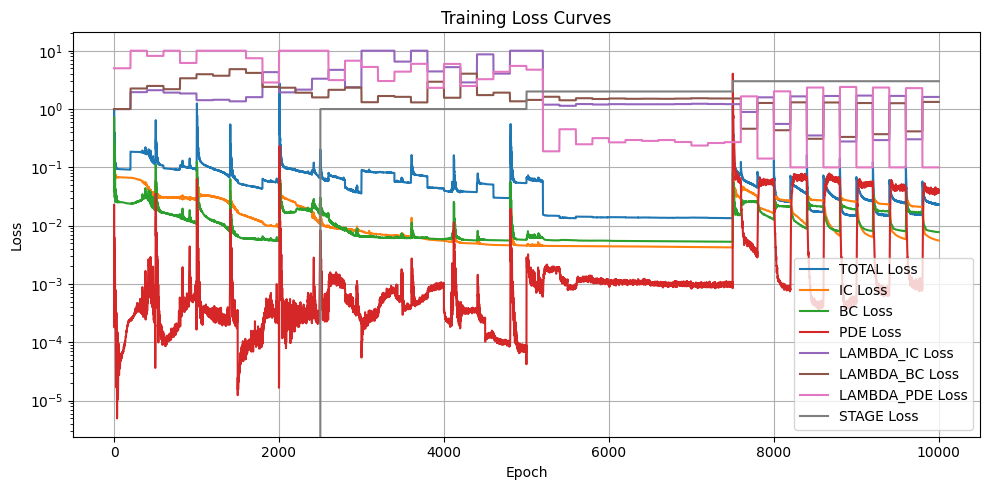

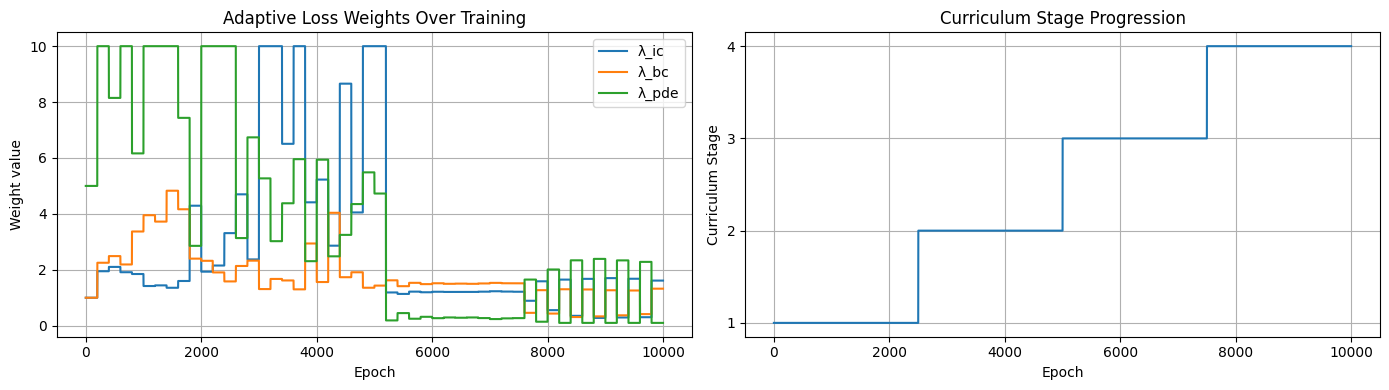

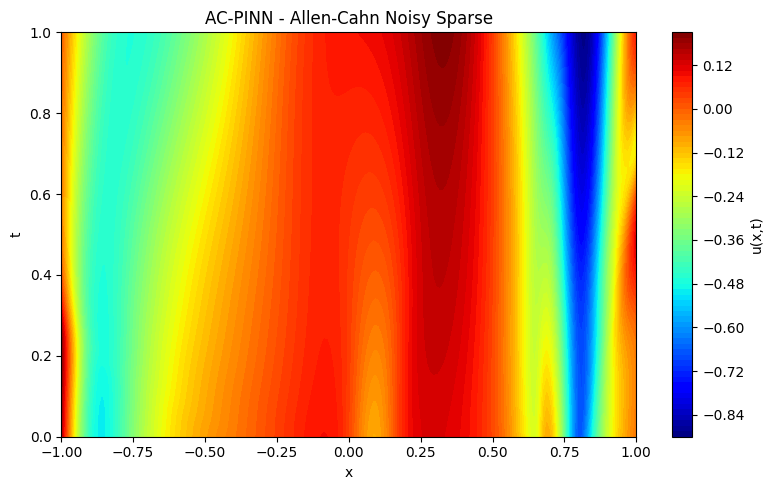

Saved: ../results/allen_cahn/ac_noisy_history.npy


In [7]:
ac_noisy = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS,
                         weight_strategy='both',
                         N_pool=30000, resample_every=500)
h_an = ac_noisy.fit(data_noisy_sparse, epochs=EPOCHS, print_every=1000, label='Allen-Cahn | AC-PINN Noisy')
ac_noisy.plot_loss_history(h_an)
ac_noisy.plot_weight_history(h_an)
ac_noisy.plot_solution(title='AC-PINN - Allen-Cahn Noisy Sparse')
save_history(h_an, RESULTS+'ac_noisy_history.npy')

## Section 7 - Benchmark vs FDM

  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla (clean)             0.338474   0.982423   0.072084   0.148377
  Vanilla (noisy)             0.521776   1.072250   0.128592   0.228732
  AC-PINN (clean)             0.997757   0.986710   0.285220   0.437388
  AC-PINN (noisy)             0.602270   1.152558   0.157961   0.264018


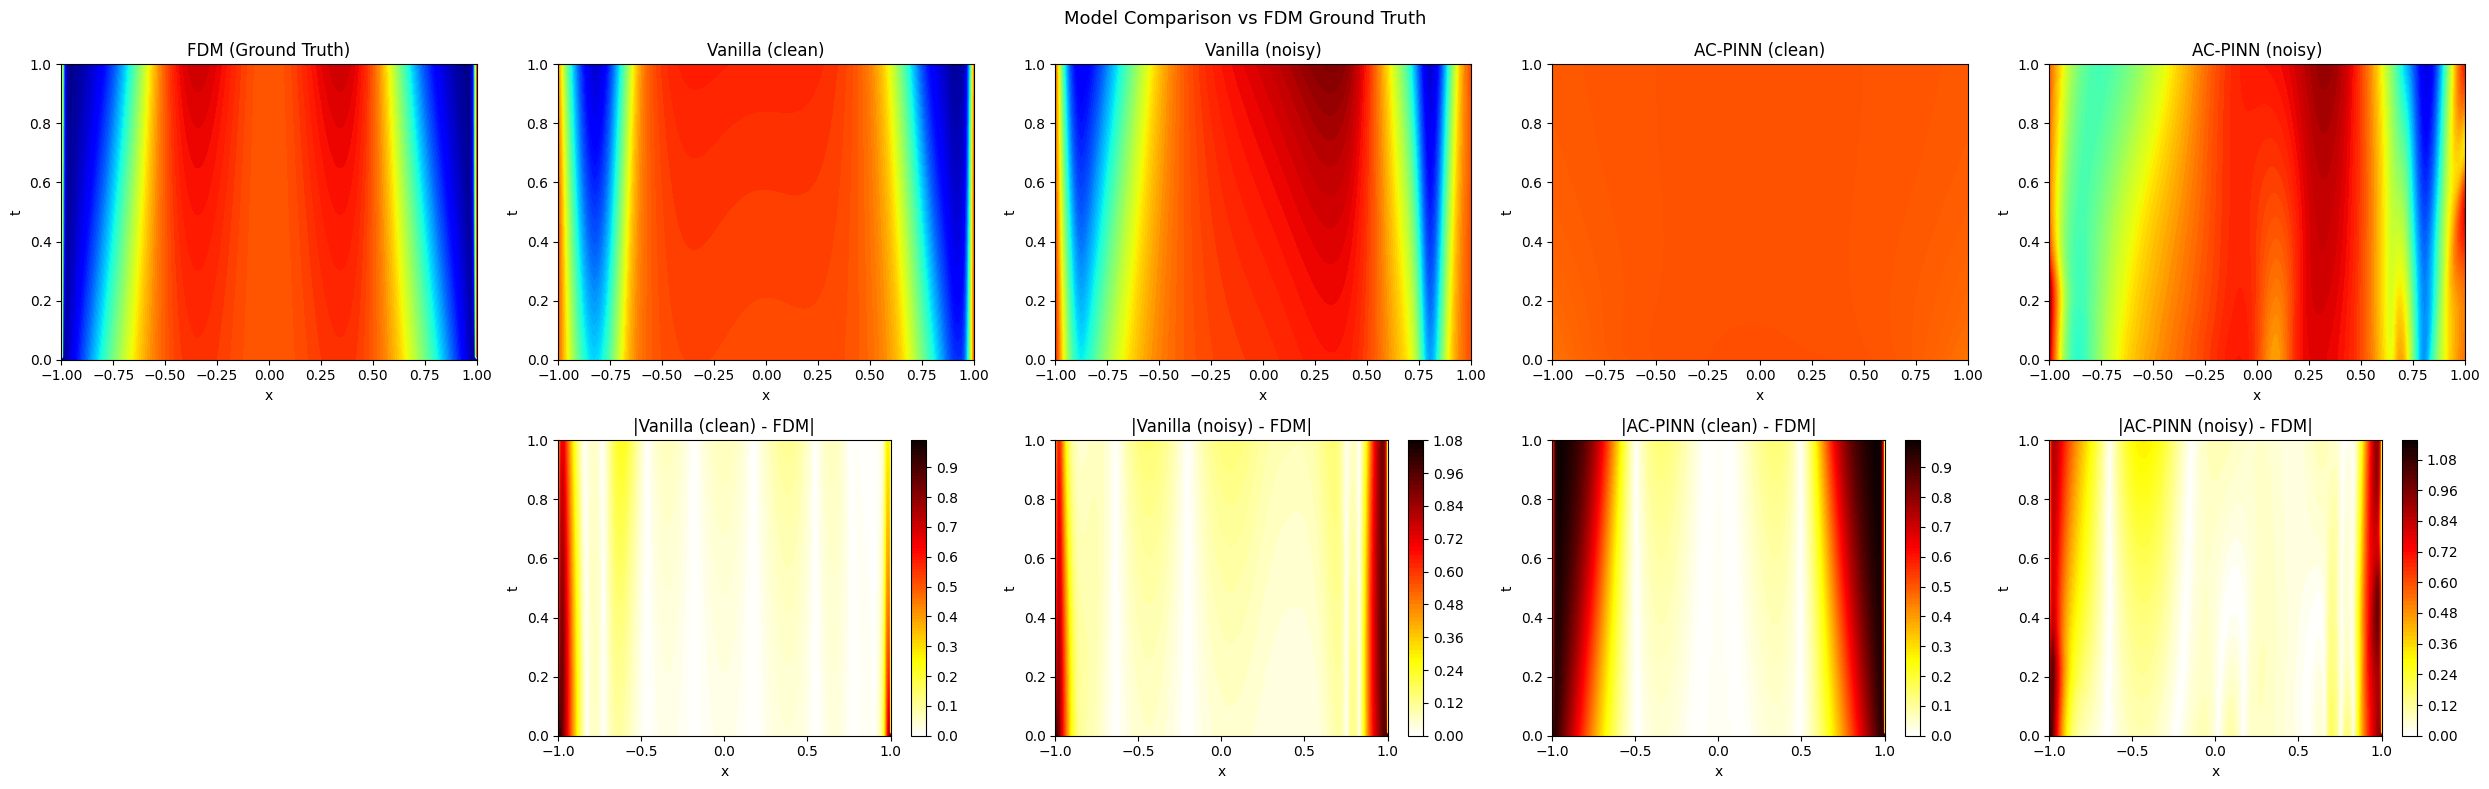

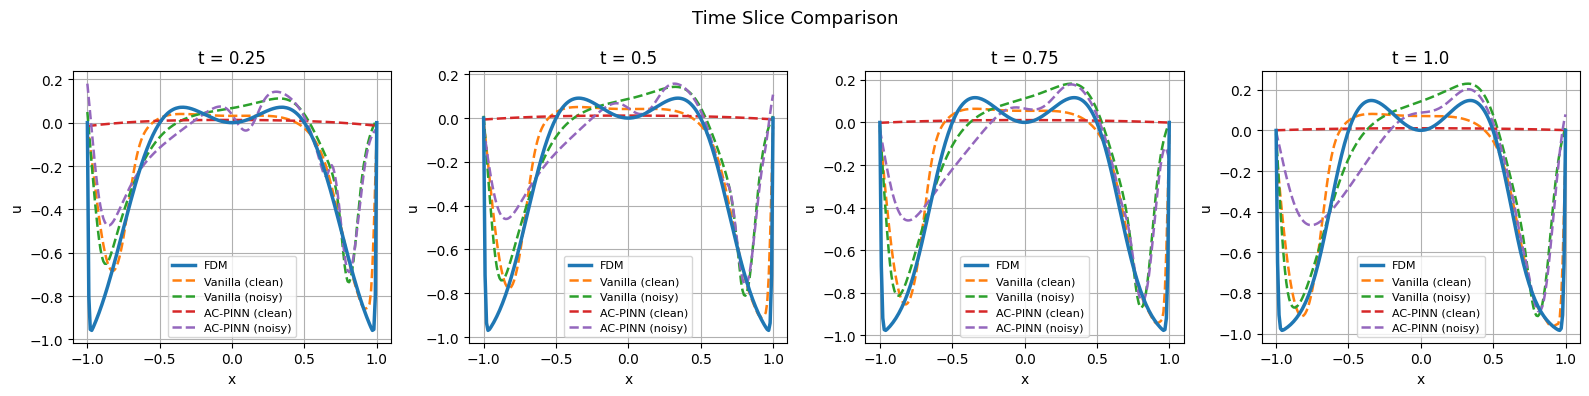

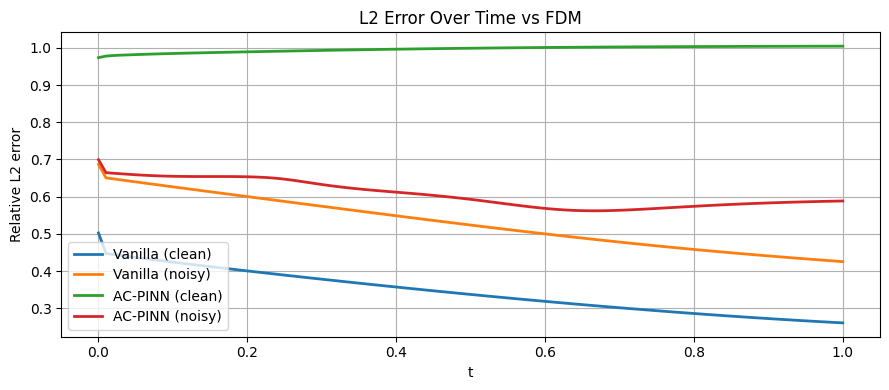

Saved: ../results/allen_cahn/benchmark_metrics.npy
Allen-Cahn experiments complete.


In [8]:
bench = Benchmark(fdm, nx=200, nt=100)
bench.add('Vanilla (clean)', vanilla_clean)
bench.add('Vanilla (noisy)', vanilla_noisy)
bench.add('AC-PINN (clean)', ac_clean)
bench.add('AC-PINN (noisy)', ac_noisy)
bench.run()

metrics = bench.compare_metrics()
bench.plot_comparison(save_path=FIGURES+'comparison.png')
bench.plot_time_slices(save_path=FIGURES+'time_slices.png')
bench.plot_error_over_time(save_path=FIGURES+'error_over_time.png')

save_metrics(metrics, RESULTS+'benchmark_metrics.npy')
print('Allen-Cahn experiments complete.')

## Section 8 - Noise Level Study

In [9]:
noise_results = {}
for eps in [0.05, 0.1, 0.2]:
    print(f'\n--- ε={eps} ---')
    d = gen.generate(N_ic=50, N_bc=50, N_f=5000, noise_eps=eps)
    v = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS, lambda_pde=10.0)
    v.fit(d, epochs=5000, print_every=2500)
    a = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS, weight_strategy='both')
    a.fit(d, epochs=5000, print_every=2500)
    b = Benchmark(fdm).add(f'Vanilla ε={eps}', v).add(f'AC-PINN ε={eps}', a)
    b.run()
    noise_results[eps] = b.compare_metrics()
save_metrics(noise_results, RESULTS+'noise_study_metrics.npy')
print('Allen-Cahn noise study complete.')


--- ε=0.05 ---


Epoch     0 | Total: 0.269497 | IC: 0.093244 | BC: 0.061392 | PDE: 0.011486


Epoch  2500 | Total: 0.099022 | IC: 0.089644 | BC: 0.006865 | PDE: 0.000251



Training complete in 88.68s
Epoch     0 | Stage 1/4 | Total: 0.120724 | IC: 0.108969 | BC: 0.011245 | PDE: 0.000102 | λ=(1.00,1.00,5.00)


Epoch  2500 | Stage 2/4 | Total: 0.042997 | IC: 0.003678 | BC: 0.006999 | PDE: 0.000531 | λ=(4.50,3.63,1.99)


...


AC-PINN training complete in 95.86s
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla ε=0.1               0.734408   1.002760   0.193181   0.321943
  AC-PINN ε=0.1               0.985141   0.990101   0.287504   0.431857

--- ε=0.2 ---
Epoch     0 | Total: 0.254259 | IC: 0.158624 | BC: 0.061464 | PDE: 0.003417


Epoch  2500 | Total: 0.110828 | IC: 0.052119 | BC: 0.056519 | PDE: 0.000219



Training complete in 88.93s
Epoch     0 | Stage 1/4 | Total: 0.266312 | IC: 0.179239 | BC: 0.086023 | PDE: 0.000210 | λ=(1.00,1.00,5.00)


Epoch  2500 | Stage 2/4 | Total: 0.320729 | IC: 0.035240 | BC: 0.054824 | PDE: 0.000017 | λ=(7.23,1.20,10.00)



AC-PINN training complete in 95.81s
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla ε=0.2               0.792753   1.064145   0.206260   0.347520
  AC-PINN ε=0.2               0.783170   1.040548   0.195998   0.343319
Saved: ../results/allen_cahn/noise_study_metrics.npy
Allen-Cahn noise study complete.
